# E3 — depth-retuned 3-well Müller–Brown (10D)

**Target.** Standard Müller–Brown functional form with depth parameters retuned to equal-depth wells, embedded in 10D ($U(z)=V_3(z_1,z_2)+\|z_{3:10}\|^2/(2\cdot0.4^2)$, $x=zB^\top$), at $\beta=24$. The standard MB is multimodal OR metastable but never both (its depth gap $0.659$ exceeds every barrier except A's own exit $0.401$); retuning $(D_1,D_3)$ to equal depths ($V=-0.7957$) decouples depth from barrier and makes $\beta$ a free dial. At $\beta=24$ the target is genuinely **trimodal AND metastable with two timescales**: $A\leftrightarrow B$ slow ($\beta b=11.1$, local methods cannot cross in $T=200$), $B\leftrightarrow C$ moderate ($\beta b=4.0$). Masses $p^\star\approx(0.32,0.42,0.26)$. Runs start in well $C$; only nonlocal relay jumps populate the far well $A$. Metrics in latent 2D $z_{1:2}$ (full-10D sliced $W_2$ in the CSV).

In [1]:
EXPERIMENT = "mb3well_10d"
import os, sys, math, time, json
sys.path.insert(0, os.path.abspath(".."))
from src.gpu_guard import select_gpu
select_gpu(int(os.environ.get("JCP_GPU", "4")))
import torch
assert torch.cuda.device_count() == 1
torch.set_default_dtype(torch.float64)
import numpy as np
import pandas as pd

from src import config as C
from src.experiments import (build_e3, make_sampler_factory,
                             make_batched_factory, make_metrics)
from src.runner import (run_experiment_batched, run_one, refine_dt,
                        quadrature_refinement, write_timeseries_csv,
                        write_summary_csv, write_manifest,
                        ula_first_passage, hardware_manifest)
from src.samplers import tune_ladder
from src.certificate import make_phi_family, certificate_grid, certificate_importance
from src.plotting import metric_grid

DEV = "cuda"
RESULTS = os.path.abspath(os.path.join("..", "results", EXPERIMENT))
FIGURES = os.path.abspath(os.path.join("..", "figures", EXPERIMENT))
os.makedirs(RESULTS, exist_ok=True); os.makedirs(FIGURES, exist_ok=True)
exp = build_e3(device=DEV, basin_cache=os.path.join(RESULTS, "basin_map.npz"))
cfg = exp.cfg
# method matrix: default = the 7 exact methods; override with JCP_METHODS (comma-
# separated) e.g. run_production.sh sets E1/E2 = exact + RA dual-run, E3/E4 = RA.
RUN_METHODS = os.environ.get("JCP_METHODS", ",".join(C.METHODS)).split(",")
print(f"experiment={cfg.name}  d={cfg.d}  N={cfg.n_particles}  T={cfg.T}  dt0={cfg.dt}")
print(f"beta={cfg.beta}  eps={cfg.eps}  lambda={cfg.lam}  seeds={cfg.seeds}")
print("RUN_METHODS:", RUN_METHODS)
print(hardware_manifest())

experiment=mb3well_10d  d=10  N=2000  T=200.0  dt0=0.005
beta=24.0  eps=0.041666666666666664  lambda=1.0  seeds=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15)
RUN_METHODS: ['ULA', 'MALA', 'FLA', 'BAOAB', 'PT', 'CP', 'LSC-CP-MA']


{'cpu': 'AMD EPYC 9554 64-Core Processor', 'gpu': 'NVIDIA H200 NVL', 'torch': '2.13.0+cu130', 'cuda': '13.0', 'python': '3.12.13', 'git_sha': 'bc8fa898a27067cacb0612a47d68e4f6929113a1', 'cuda_visible_devices': '0', 'gpu_compute_apps_at_start': ['GPU-514c2f3b-34cc-98a9-dfa1-7671c8c08767, 1452802, 1160 MiB', 'GPU-7a3fde0b-37cf-0cd6-97e7-2385d6ebfaf2, 1168205, 1788 MiB', 'GPU-c8768979-ae7d-8ca1-a33d-2874c9d21fae, 791626, 31878 MiB', 'GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 791627, 32008 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 791628, 32010 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 4103055, 814 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 791629, 31896 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 1382558, 7582 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 1421419, 67188 MiB']}


In [2]:
from src.potentials import MB3_CRITICAL, mb3_2d, mb3_2d_grad, newton_refine
for key, (z_tab, V_tab) in MB3_CRITICAL.items():
    z = newton_refine(mb3_2d_grad, torch.tensor(z_tab, device=DEV))
    Vv = mb3_2d(z.unsqueeze(0))[0].item()
    assert abs(Vv - V_tab) < 5e-4, (key, Vv)
    print(f"{key:5s}: ({z[0].item():+.4f}, {z[1].item():+.4f})  V = {Vv:.4f}")
b_AB, b_BC = exp.extras["b_AB"], exp.extras["b_BC"]
print(f"p_star (A,B,C): {np.round(exp.p_star.cpu().numpy(), 4)} | "
      f"beta*b(A<->B) = {cfg.beta*b_AB:.1f} (slow) | "
      f"beta*b(B<->C) = {cfg.beta*b_BC:.1f} (moderate)")

# barrier structure: ULA from C reaches B (B<->C moderate) but NOT A (A<->B slow)
g = torch.Generator(device=DEV); g.manual_seed(0)
rep_A = ula_first_passage(exp.pot, exp.box, exp.init_fn(cfg.n_particles, g),
                          exp.exit_committed, cfg.dt, int(cfg.T/cfg.dt), cfg.eps, g)
g2 = torch.Generator(device=DEV); g2.manual_seed(0)
rep_B = ula_first_passage(exp.pot, exp.box, exp.init_fn(cfg.n_particles, g2),
                          exp.extras["exit_to_B"], cfg.dt, int(cfg.T/cfg.dt), cfg.eps, g2)
# Kramers estimate of the expected number of A-crossings over the N*T budget:
# a handful is fine (rare-event fluctuation); what matters is that ULA does NOT
# populate A at its equilibrium mass p*_A -- committed-exit fraction << p*_A.
_exp_cross = rep_A['n_particles'] * (1.0 - math.exp(-cfg.T / max(exp.kramers_tau, 1e-30)))
print(f"ULA T={cfg.T}: committed C->A (far well) = {rep_A['n_exits']}/{rep_A['n_particles']} "
      f"(frac {rep_A['exit_fraction']:.4f}; Kramers expects ~{_exp_cross:.1f}, "
      f"<< equilibrium p*_A={float(exp.p_star[0]):.2f}) | "
      f"C->B (reachable) = {rep_B['n_exits']}/{rep_B['n_particles']} (expect > 0)")
assert rep_A['exit_fraction'] < 0.2 * float(exp.p_star[0]),     "local ULA must stay far from equilibrating the far well A"
assert rep_B['n_exits'] > 0, "B<->C must be reachable (two-timescale structure)"
# barrier_report is consumed by the shared manifest cell (far-well C->A passage)
barrier_report = {**rep_A, "exit_to_B_fraction": rep_B["exit_fraction"],
                  "kramers_tau": exp.kramers_tau}
print(f"Kramers tau(A<->B) = {exp.kramers_tau:.2e} time units >> T={cfg.T}")

A    : (-0.5872, +1.4127)  V = -0.7956
B    : (-0.0655, +0.4755)  V = -0.7957
C    : (+0.5739, +0.0386)  V = -0.7956
S_AB : (-0.9164, +0.6656)  V = -0.3323
S_BC : (+0.2659, +0.2472)  V = -0.6310
p_star (A,B,C): [0.3102 0.4209 0.2689] | beta*b(A<->B) = 11.1 (slow) | beta*b(B<->C) = 4.0 (moderate)


ULA T=200.0: committed C->A (far well) = 5/2000 (frac 0.0025; Kramers expects ~0.9, << equilibrium p*_A=0.31) | C->B (reachable) = 2000/2000 (expect > 0)
Kramers tau(A<->B) = 4.25e+05 time units >> T=200.0


## Target density: explicit form and visualization

The target is $\pi(x)\propto e^{-\beta U(x)}$ on $\mathbb R^{10}$ at $\beta=24$. In latent coordinates $z = xB^{-\top}$ ($x = zB^\top$, $B = Q\,\mathrm{diag}(0.75,\dots,1.45)$, $Q$ a frozen Haar rotation from `default_rng(12345)`):

$$U(z) = V_3(z_1,z_2) + \frac{\|z_{3:10}\|^2}{2\sigma_{\mathrm{aux}}^2},\qquad \sigma_{\mathrm{aux}}=0.4,$$

$$V_3(z_1,z_2) = \sum_{k=1}^{4} D_k\, \exp\!\big(a_k(z_1-\bar x_k)^2 + b_k(z_1-\bar x_k)(z_2-\bar y_k) + c_k(z_2-\bar y_k)^2\big),$$

the **standard Müller–Brown functional form** with depths $(D_1,D_3)$ retuned so the three deep wells are equal-depth:

| $k$ | $D_k$ | $a_k$ | $b_k$ | $c_k$ | $\bar x_k$ | $\bar y_k$ |
|---|---|---|---|---|---|---|
| 1 | $-1.6607$ | $-1$   | $0$  | $-10$  | $1$    | $0$    |
| 2 | $-1.0$    | $-1$   | $0$  | $-10$  | $0$    | $0.5$  |
| 3 | $-1.0218$ | $-6.5$ | $11$ | $-6.5$ | $-0.5$ | $1.5$  |
| 4 | $+0.15$   | $0.7$  | $0.6$| $0.7$  | $-1$   | $1$    |

**Why retuned.** The standard MB's depth gap $V_B-V_A=0.659$ exceeds every barrier but A's own exit ($0.401$): any $\beta$ equalising the masses ($\beta\lesssim4.6$) kills metastability, any $\beta$ creating metastability ($\beta\gtrsim25$) makes the mass ratio $e^{-16}$ (effectively unimodal). Retuning to equal-depth wells decouples the two exponentials, so $\beta$ becomes a free dial. Since $x=zB^\top$ is invertible linear, $\pi$ factorises exactly: $\pi(z)=\frac{e^{-\beta V_3}}{Z_2}\prod_{j=3}^{10}\mathcal N(z_j;0,\sigma_{\mathrm{aux}}^2)$ — all multimodal structure is in the 2D marginal below.

In [3]:
# Target visualization (self-contained, CPU-safe; touches no run state).
import os, sys, math
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import torch
import matplotlib.pyplot as plt
from src.potentials import mb3_2d, MB3_CRITICAL

beta_viz = float(cfg.beta)
zg1 = torch.linspace(-1.3, 1.3, 701, dtype=torch.float64)
zg2 = torch.linspace(-0.6, 1.9, 701, dtype=torch.float64)
ZZ = torch.stack(torch.meshgrid(zg1, zg2, indexing="ij"), dim=-1)
Vg = mb3_2d(ZZ)
cell_area = float((zg1[1] - zg1[0]) * (zg2[1] - zg2[0]))
logp2 = -beta_viz * Vg
logp2 = logp2 - (torch.logsumexp(logp2.reshape(-1), 0) + math.log(cell_area))

wells = ["A", "B", "C"]
zw = torch.tensor([MB3_CRITICAL[k][0] for k in wells], dtype=torch.float64)
lab_g = torch.cdist(ZZ.reshape(-1, 2), zw).argmin(1)
p2_flat = torch.exp(logp2.reshape(-1))
mass = torch.tensor([float(p2_flat[lab_g == i].sum()) for i in range(3)])
mass = mass / mass.sum()
print("latent-2D grid well masses (A,B,C):", np.round(mass.numpy(), 4),
      " (cf. p_star printed above)")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
lv = np.linspace(-0.85, 0.2, 22)
cf0 = axes[0].contourf(zg1, zg2, Vg.T, levels=lv, cmap="viridis")
axes[0].contour(zg1, zg2, Vg.T, levels=lv, colors="k", linewidths=0.25, alpha=0.4)
for k in wells:
    (zx, zy), Vk = MB3_CRITICAL[k]
    axes[0].plot(zx, zy, "o", ms=5, mfc="w", mec="k")
    axes[0].annotate(f"{k}  V={Vk:.3f}", (zx, zy), textcoords="offset points",
                     xytext=(7, 5), fontsize=8, color="w")
for s in ("S_AB", "S_BC"):
    (sx, sy), Vs = MB3_CRITICAL[s]
    axes[0].plot(sx, sy, "x", ms=7, color="r")
    axes[0].annotate(f"{s}  V={Vs:.3f}", (sx, sy), textcoords="offset points",
                     xytext=(-7, -3), ha="right", fontsize=8, color="r")
axes[0].set(title=r"latent potential $V_3(z_1, z_2)$ (depth-retuned)",
            xlabel="$z_1$", ylabel="$z_2$")
fig.colorbar(cf0, ax=axes[0], label="$V_3$")

l10 = (logp2 / math.log(10.0)).numpy()
lv1 = np.linspace(l10.max() - 8.0, l10.max(), 33)
cf1 = axes[1].contourf(zg1, zg2, np.maximum(l10.T, lv1[0]), levels=lv1, cmap="magma")
for k, m in zip(wells, mass):
    (zx, zy), _ = MB3_CRITICAL[k]
    axes[1].annotate(f"{k}: {float(m):.3f}", (zx, zy), textcoords="offset points",
                     xytext=(7, 5), fontsize=8, color="w")
axes[1].set(title=r"2D marginal $\log_{10}\pi_2$ at $\beta=24$ (labels: basin masses)",
            xlabel="$z_1$", ylabel="$z_2$")
fig.colorbar(cf1, ax=axes[1], label=r"$\log_{10}\pi_2$")
os.makedirs(os.path.join("..", "figures", "mb3well_10d"), exist_ok=True)
for ext in ("png", "pdf"):
    fig.savefig(os.path.join("..", "figures", "mb3well_10d",
                             "mb3well_10d_target." + ext), dpi=200, bbox_inches="tight")
plt.show()

latent-2D grid well masses (A,B,C): [0.3102 0.4202 0.2696]  (cf. p_star printed above)


## Jump law and Lévy score

**Relay design.** Four atoms $\{\pm r_{BA},\ \pm r_{BC}\}$ through the middle hub $B$ ($r_{BA}=z_A-z_B$, $r_{BC}=z_C-z_B$ in latent coords, then $r=(\Delta z,0_8)B^\top$), $w_a=\tfrac14$, shell $h=0.1\min\|r_a\|$, $\lambda=1$; the CP pair's drift step is capped at $2h$ (the $B$–$A$ chord overshoots $S_{AB}$, so the detailed-balance return flux is integrated with small in-tube steps). **No direct $A$–$C$ atom** — the two-hop relay through $B$ covers it. The atom set is FIXED and every atom fires from every state (never gated on the current basin — a state-dependent selection law would break the RA invariance argument). Score: generic shell with log-space accumulation; certificate on the exact latent-2D reduction (per-atom residuals cover the RA estimator).

In [4]:
from src.potentials import MB3Latent2D
from src.jumps import ShellJumpLaw
from src.score import ShellScore
potr = MB3Latent2D()
dz = exp.extras["atoms_z"][:, :2]
h_z = exp.extras["h"] * dz.norm(dim=1) / exp.law.atoms.norm(dim=1)
law_r = ShellJumpLaw(dz, exp.law.weights.clone(), h_z)
clo, chi = exp.extras["cert_lo"], exp.extras["cert_hi"]   # generous box (>= 1 jump)
print("relay atoms (latent):", np.round(dz.cpu().numpy(), 3).tolist())
print("h =", round(exp.extras["h"], 4), " drift cap (CP pair) =",
      round(exp.cp_drift_cap, 4))
DEFAULT_QUAD = dict(q_theta=C.Q_THETA, q_rho=C.Q_RHO)
phis = make_phi_family(2, [0.0, 0.5], 0.8, DEV)

def cert_e3(q_theta, q_rho):
    score = ShellScore(potr, law_r, cfg.lam, cfg.beta, q_theta, q_rho)
    shifts, logw = law_r.quadrature_shifts(64)
    return certificate_grid(potr, score, shifts, logw, cfg.lam, cfg.beta, phis,
                            list(clo), list(chi),
                            n_panels=200, nodes_per_panel=10, chunk=8192)

cert_report = cert_e3(**DEFAULT_QUAD)
print(f"max R = {cert_report['max_residual']:.3e}")
assert cert_report["max_residual"] < 1e-6

relay atoms (latent): [[-0.522, 0.937], [0.522, -0.937], [0.639, -0.437], [-0.639, 0.437]]
h = 0.0601  drift cap (CP pair) = 0.1201


max R = 9.418e-15


In [5]:
# PT: geometric ladder beta_k = beta * r^(k-1); K tuned so the post-burn-in
# swap acceptance lands in [0.2, 0.4]
gen = torch.Generator(device=DEV); gen.manual_seed(0)
x0_pilot = exp.init_fn(min(512, cfg.n_particles), gen)
pt_betas, ladder_info = tune_ladder(exp.pot, x0_pilot, cfg.dt, exp.box,
                                    cfg.beta, exp.pt_beta_min, pilot_steps=20_000)
print(f"PT ladder: K={ladder_info['K']}  r={ladder_info['r']:.4f}  "
      f"beta_K={pt_betas[-1].item():.4f}  swap acceptance={ladder_info['swap_acceptance']:.3f}"
      f"  band_attained={ladder_info['band_attained']}")

PT ladder: K=4  r=0.5644  beta_K=4.3159  swap acceptance=0.372  band_attained=True


In [6]:
# frozen reference sample (size N), frozen sliced-W2 projections, frozen MMD
# bandwidth (median heuristic on the reference); bias floors from 20
# independent reference pairs. EMC convention: exp(H(p_hat))/K for uniform
# p*, 1 - EJS(p_hat, p*) otherwise -- near 1 is better in both cases.
metrics_fn, floors, aux = make_metrics(exp, cfg.n_particles)
emc_target = exp.emc_target
print("p_star:", np.round(exp.p_star.cpu().numpy(), 6),
      " uniform:", exp.uniform_target)
print("MMD bandwidth:", round(aux["bandwidth"], 4))
for k, v in floors.items():
    print(f"  floor {k:>12s}: {v['mean']:.5f} +- {v['std']:.5f}")

p_star: [0.310225 0.420923 0.268852]  uniform: False
MMD bandwidth: 0.8337
  floor           W2: 0.04975 +- 0.02024
  floor          MMD: 0.01841 +- 0.00765
  floor           TV: 0.01085 +- 0.00734
  floor          EMC: 0.99985 +- 0.00017
  floor       W2_10d: 0.01223 +- 0.00361


/home/zheyuanlai/levy-sampling/JCP_experiments/src/metrics.py:142: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  idx = torch.bucketize(cv.reshape(-1), edges[1:-1])


In [7]:
# the run's LSC estimator (exact LSC-CP, or a practical RA/MA variant)
_LSC = next((m for m in RUN_METHODS if m.startswith("LSC-CP")), "LSC-CP")
def run_terminal_lsc(**quad):
    f = make_sampler_factory(exp, cfg.dt, pt_betas, score_kwargs=quad)
    n_ = int(round(cfg.T / cfg.dt))
    r_, _ = run_one(_LSC, 0, f, n_, n_, cfg.dt, metrics_fn, exp.pot, quiet=True)
    return {k: r_[-1][k] for k in ("W2", "TV", "MMD", "EMC", "W2_10d")}

settings = [dict(q_theta=qt, q_rho=qr) for qt in (8, 16, 32) for qr in (4, 8, 16)]
CHOSEN_QUAD, quad_table = quadrature_refinement(
    settings, run_terminal_lsc, lambda **s: cert_e3(**s)["max_residual"], floors)
print("chosen quadrature:", CHOSEN_QUAD)
display(pd.DataFrame(quad_table).round(6))

chosen quadrature: {'q_theta': 8, 'q_rho': 4}


,q_theta,q_rho,R,W2,TV,MMD,EMC,W2_10d,pass
0,8,4,0.0,0.046485,0.013352,0.011180,0.999777,0.012878,True
1,8,8,0.0,0.046485,0.013352,0.011180,0.999777,0.012878,True
2,8,16,0.0,0.046485,0.013352,0.011180,0.999777,0.012878,True
3,16,4,0.0,0.057486,0.008852,0.011256,0.999927,0.014015,True
4,16,8,0.0,0.057486,0.008852,0.011256,0.999927,0.014015,True
5,16,16,0.0,0.057486,0.008852,0.011256,0.999927,0.014015,True
6,32,4,0.0,0.057346,0.008352,0.011121,0.999935,0.013998,True
7,32,8,0.0,0.057346,0.008352,0.011121,0.999935,0.013998,True
8,32,16,0.0,0.057346,0.008352,0.011121,0.999935,0.013998,True


In [8]:
# dt rule: largest dyadic dt at which every PI-TARGETING method's terminal
# metrics agree with dt/2 (5% / floor-band / 4-sigma noise guards); FLA and
# raw CP have invariant laws != pi and are recorded but do not gate.
# Production: all seeds batched into one (S*N)-particle ensemble per method.
MAIN_METRICS = ["W2", "TV", "MMD", "EMC", "W2_10d"]

def run_terminal_all(dt_):
    n_ = int(round(cfg.T / dt_))
    factory = make_sampler_factory(exp, dt_, pt_betas, score_kwargs=CHOSEN_QUAD)
    out = {}
    for m in RUN_METHODS:
        rows_, _ = run_one(m, 0, factory, n_, n_, dt_, metrics_fn, exp.pot, quiet=True)
        out[m] = {k: rows_[-1][k] for k in MAIN_METRICS}
    print(f"  refine_dt: finished pass at dt={dt_}", flush=True)
    return out

dt_final, dt_table = refine_dt(run_terminal_all, cfg.dt, floors,
                               exclude=("FLA", "CP", "CP-RA"))
print("chosen dt:", dt_final)
for row in dt_table:
    print(row)

n_steps = int(round(cfg.T / dt_final))
steps_per_ck = max(1, n_steps // C.N_CHECKPOINTS)
# dense-early checkpoint schedule: the nonlocal transient lives in the
# first ~5% of the run; 60 dense + 160 sparse points, identical across
# methods (measurement cadence only -- no protocol change)
from src.runner import checkpoint_schedule
ck_steps = checkpoint_schedule(n_steps)
bfactory = make_batched_factory(exp, dt_final, pt_betas, cfg.seeds,
                                score_kwargs=CHOSEN_QUAD)
t0 = time.time()
rows, method_info = run_experiment_batched(RUN_METHODS, cfg.seeds, bfactory,
                                           n_steps, steps_per_ck, dt_final,
                                           metrics_fn, exp.pot,
                                           cfg.n_particles,
                                           checkpoint_steps=ck_steps)
print(f"production total: {time.time()-t0:.0f}s")
assert max(r["nonfinite_frac"] for r in rows) == 0.0
print("nonfinite fraction: identically zero")

  refine_dt: finished pass at dt=0.005


  refine_dt: finished pass at dt=0.0025


chosen dt: 0.005
{'dt': 0.005, 'pass': True, 'failures': [], 'excluded_deviations': [('FLA', 'TV', 0.106352, 0.066275), ('FLA', 'W2_10d', 0.104817, 0.08345)]}


ULA: done in 49.1s (batched 16 seeds)


MALA: done in 74.4s (batched 16 seeds)


...

BAOAB: done in 49.9s (batched 16 seeds)


PT: done in 79.6s (batched 16 seeds)


CP: done in 60.1s (batched 16 seeds)


LSC-CP-MA: done in 105.3s (batched 16 seeds)


production total: 471s
nonfinite fraction: identically zero


In [9]:
# pi-start hold test: initialise at the reference and measure any stationary
# drift of the discretised LSC-CP chain
K = exp.p_star.shape[0]
g_h = torch.Generator(device=DEV); g_h.manual_seed(777)
x_pi = exp.ref_sample(4000, g_h)
from src.metrics import occupancy as _occ
bf = make_batched_factory(exp, dt_final, pt_betas, (0,), n_particles=4000,
                          score_kwargs=CHOSEN_QUAD)
s_h = bf(_LSC)                       # the run's LSC estimator (exact / RA / MA)
s_h.x = x_pi.clone()
p0 = _occ(exp.labels_fn(s_h.positions()), K)
for _i in range(int(round(100.0 / dt_final))):
    s_h.step()
p1 = _occ(exp.labels_fn(s_h.positions()), K)
hold_tv = 0.5 * float((p1 - exp.p_star).abs().sum())
pi_start_hold = {"init": [round(float(v), 4) for v in p0],
                 "after_T100": [round(float(v), 4) for v in p1],
                 "TV_vs_pstar": round(hold_tv, 4)}
print("pi-start hold:", pi_start_hold)

pi-start hold: {'init': [0.3048, 0.4245, 0.2707], 'after_T100': [0.3183, 0.4228, 0.259], 'TV_vs_pstar': 0.0099}


plotted methods: ['ULA', 'MALA', 'FLA', 'BAOAB', 'PT', 'CP', 'LSC-CP-MA']  labels: {'CP': 'Raw-CP', 'LSC-CP-MA': 'LSC-CP'}


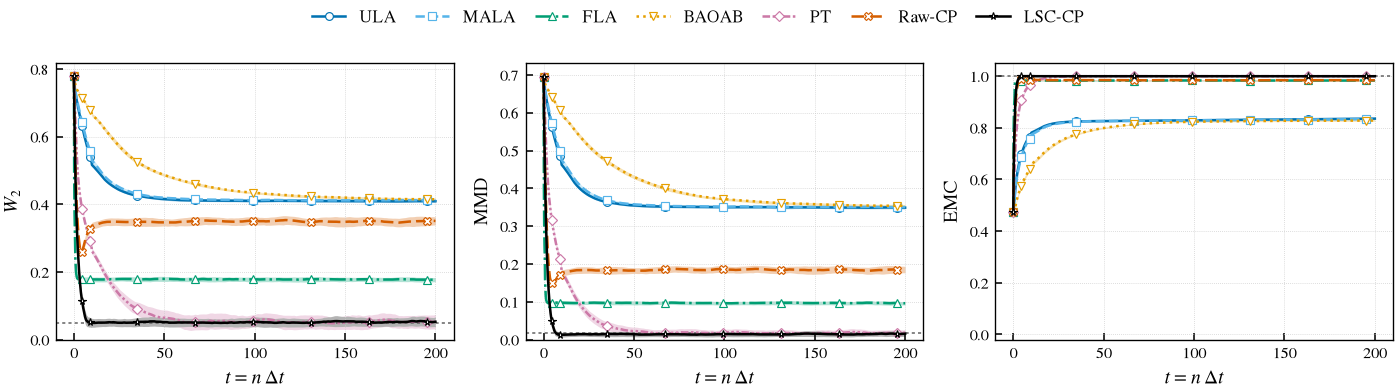

saved: /home/zheyuanlai/levy-sampling/JCP_experiments/figures/mb3well_10d/mb3well_10d_metrics.{png,pdf}


saved per-metric log-y figures: ['W2', 'TV', 'MMD', 'e_F', 'basin_rel_max', 'KSD', 'W1_cdf', 'CDF_sup', 'pdf_L1', 'KDE_chi2', 'W2_10d'] x {t, nfe, wallclock}


split-Rhat(occ0) | final NFE:
  ULA        : Rhat=2.755  NFE=1.28e+09
  MALA       : Rhat=2.964  NFE=2.56e+09
  FLA        : Rhat=1.004  NFE=1.28e+09
  BAOAB      : Rhat=3.768  NFE=1.28e+09
  PT         : Rhat=1.036  NFE=1.02e+10
  CP         : Rhat=1.034  NFE=1.28e+09
  LSC-CP-MA  : Rhat=1.009  NFE=4.35e+10


In [10]:
from src.plotting import metric_single
from src.runner import convergence_report
# plotted-method policy: figures show ONE LSC-CP line -- the practical
# estimator advocated for this experiment (multi-atom if run, else single-atom
# RA, else exact), labeled "LSC-CP". When the exact-score run is also in the
# matrix (E1/E2 dual-run) it stays in the CSV as the estimator-agreement
# record but is not drawn: the estimators agree within the seed band, and a
# second black line only clutters / stretches the cost axes.
PLOT_LSC = next((m for m in ("LSC-CP-MA", "LSC-CP-RA", "LSC-CP")
                 if m in RUN_METHODS), "LSC-CP")
PLOT_RAW = "CP" if "CP" in RUN_METHODS else "CP-RA"
PLOT_METHODS = [m for m in ("ULA", "MALA", "FLA", "BAOAB", "PT")
                if m in RUN_METHODS] + [PLOT_RAW, PLOT_LSC]
PLOT_LABELS = {PLOT_RAW: "Raw-CP", PLOT_LSC: "LSC-CP"}
print("plotted methods:", PLOT_METHODS, " labels:", PLOT_LABELS)

fig = metric_grid(rows, os.path.join(FIGURES, EXPERIMENT + "_metrics"),
                  metrics=("W2", "MMD", "EMC"), floors=floors,
                  emc_target=emc_target, methods=PLOT_METHODS,
                  label_overrides=PLOT_LABELS)
print("saved:", os.path.join(FIGURES, EXPERIMENT + "_metrics") + ".{png,pdf}")

# per-metric log-y single figures on t / NFE / wall-clock axes (all curves start
# at the shared n=0 point; linear x so t=0 / NFE=0 is representable; the cost
# axes are truncated at the largest non-LSC terminal x -- metric_single's
# xmax_mode="baselines" -- so the 10-30x-per-step LSC-CP curve cannot squeeze
# every baseline against the y-axis)
_present = set().union(*[set(r) for r in rows])
# FULL metric list -- must stay in sync with scripts/replot_figures.py _SINGLE:
# every per-metric figure on disk is regenerated here, so none can go stale
# with old data/axes when the notebook re-runs
_single = [m for m in ("W2", "TV", "TV_density", "MMD", "e_F",
                       "basin_rel_max", "KSD", "W1_cdf", "CDF_sup",
                       "pdf_L1", "KDE_chi2", "W2_10d") if m in _present]
for _m in _single:
    for _axis in ("t", "nfe", "wallclock"):
        metric_single(rows, _m, os.path.join(FIGURES, f"{EXPERIMENT}_{_m}_{_axis}"),
                      xaxis=_axis, floors=floors, methods=PLOT_METHODS,
                      emc_target=emc_target, label_overrides=PLOT_LABELS,
                      show=False)
print("saved per-metric log-y figures:", _single, "x {t, nfe, wallclock}")

# cross-seed convergence: rank-normalized split-Rhat on the slow basin-0
# occupancy (each seed a chain); metastable targets that trap seeds -> Rhat >> 1
# (reported for ALL run methods, including any undrawn exact-score run)
conv = convergence_report(rows, RUN_METHODS, cfg.seeds)
print("split-Rhat(occ0) | final NFE:")
for _mth, _d in conv.items():
    print(f"  {_mth:11s}: Rhat={_d['split_rhat']:.3f}  NFE={_d['final_nfe']:.3g}")

In [11]:
ts_path = os.path.join(RESULTS, "metrics_timeseries.csv")
write_timeseries_csv(rows, ts_path)
summary_metrics = MAIN_METRICS + ["nonfinite_frac"]
summary = write_summary_csv(rows, RUN_METHODS, cfg.seeds, summary_metrics,
                            method_info, floors, os.path.join(RESULTS, "summary.csv"))

# plot policy recomputed here (not inherited from the figures cell) so the
# manifest is self-contained even if cells are run out of order; it makes
# results/<exp>/ sufficient to regenerate every figure with no GPU
# (scripts/replot_figures.py reads it).
_plot_lsc = next((m for m in ("LSC-CP-MA", "LSC-CP-RA", "LSC-CP")
                  if m in RUN_METHODS), "LSC-CP")
_plot_raw = "CP" if "CP" in RUN_METHODS else "CP-RA"
manifest = dict(
    experiment=EXPERIMENT,
    config=dict(d=cfg.d, N=cfg.n_particles, T=cfg.T, dt0=cfg.dt, dt=dt_final,
                beta=cfg.beta, eps=cfg.eps, lam=cfg.lam, seeds=list(cfg.seeds),
                n_checkpoints=C.N_CHECKPOINTS, warmup_steps=C.N_WARMUP_STEPS,
                batched_seeds=True),
    emc_target=float(emc_target),
    p_star=[float(v) for v in exp.p_star.cpu()],
    plot=dict(
        methods=[m for m in ("ULA", "MALA", "FLA", "BAOAB", "PT")
                 if m in RUN_METHODS] + [_plot_raw, _plot_lsc],
        label_overrides={_plot_raw: "Raw-CP", _plot_lsc: "LSC-CP"}),
    quadrature=dict(chosen=CHOSEN_QUAD, table=quad_table),
    dt_refinement=[{k: (str(v) if isinstance(v, tuple) else v) for k, v in row.items()}
                   for row in dt_table],
    pt_ladder={k: v for k, v in ladder_info.items()},
    certificate=cert_report,
    bias_floors=floors,
    barrier_verification=barrier_report,
    method_info={m: {k: v for k, v in mi.items() if isinstance(v, (int, float))}
                 for m, mi in method_info.items()},
    hardware=hardware_manifest(),
    pi_start_hold=pi_start_hold,
)
write_manifest(os.path.join(RESULTS, "manifest.json"), **manifest)
print("wrote", ts_path)
from IPython.display import display
display(pd.read_csv(os.path.join(RESULTS, "summary.csv")).round(5))

wrote /home/zheyuanlai/levy-sampling/JCP_experiments/results/mb3well_10d/metrics_timeseries.csv


,method,EMC_mean,EMC_std,MMD_mean,MMD_std,TV_mean,TV_std,V_evals_per_step,W2_10d_mean,W2_10d_std,...,jump_count_mean,m_clip_fraction,mala_accept,nonfinite_frac_mean,nonfinite_frac_std,pt_swap_accept,score_quad_evals_per_step,time_to_threshold_TV,wallclock_mean_s,wallclock_std_s
0,ULA,0.83562,0.00447,0.34848,0.00317,0.30701,0.00153,0.0,0.14066,0.00129,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,30.95833,0.0
1,MALA,0.83412,0.00390,0.35010,0.00296,0.30754,0.00126,32000.0,0.14171,0.00123,...,NaN,NaN,0.98675,0.0,0.0,NaN,0.0,inf,56.60384,0.0
2,FLA,0.98349,0.00238,0.09605,0.00399,0.11917,0.00809,0.0,0.10345,0.00888,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,34.14367,0.0
3,BAOAB,0.82819,0.00236,0.35400,0.00231,0.30929,0.00060,0.0,0.14340,0.00113,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,31.99569,0.0
4,PT,0.99979,0.00025,0.01864,0.00794,0.01334,0.00756,128000.0,0.01306,0.00374,...,NaN,NaN,0.98463,0.0,0.0,0.37188,0.0,34.940,61.65250,0.0
5,CP,0.98330,0.00158,0.18675,0.00634,0.13469,0.00627,0.0,0.11142,0.00332,...,0.00502,NaN,NaN,0.0,0.0,NaN,0.0,inf,42.21509,0.0
6,LSC-CP-MA,0.99970,0.00024,0.01301,0.00590,0.01630,0.00619,1056000.0,0.01247,0.00202,...,0.00502,0.0,NaN,0.0,0.0,NaN,0.0,5.335,86.90309,0.0
